# LGBIO2070 — Laboratory session 3: Treatment planning in proton therapy

#### *Teaching staff: Eliot Peeters, Romain Schyns, Prof. John A. Lee*
#### Contacts :
   - eliot.peeters@uclouvain.be
   - romain.schyns@uclouvain.be

#### **DUE DATE: Sunday, May 25, at 23:59:59**

#### Authors: Keppens Max, Rallo Lisa

<a target="_blank" href="https://colab.research.google.com/github/MIRO-UCLouvain/LGBIO2070_lab3/blob/main/LGBIO2070%20-%20Lab%203.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>

## 1. Data import and treamtent

In this part of the lab, you will get familiar with the data used for the proton therapy plan optimization.

### 1.1 Data import with the DICOM format

Images used in the clinic are exchanged and registered in the DICOM format, a universal file format which registers patient data together with image data. The different data fields are accessible though multiple data "[tags](https://www.dicomlibrary.com/dicom/dicom-tags/)".

- **Q1.1** Use the python library [Pydicom](https://pydicom.github.io/pydicom/stable/) to extract the DICOM provided data

As you might notice, the DICOM data is not in Hounsfield Unit (HU). To get the HU back, you will need two DICOM tags: *slope* and *intercept*. You will also need to retrieve the DICOM resolution using the *pixel spacing* and *slice thickness* tags.

- **Q1.2** Use the DICOM tags to extract the necessary information

**Hint**: the website [Innolitics](https://dicom.innolitics.com/ciods) provide comprehensive and readable information on DICOM tags

- **Q1.3** Take a moment to examine the pixel spacing and slice thickness. What do these parameters represent, and where do they come from? Can you think of any issues that might occur when visualizing the CT scan in different planes? In which orientations might these problems be most noticeable?
> *Answer here*

The pixel spacing represents the physical distance that corresponds to each pixel on the image, while the slice thickness represents the physical distance between two consecutive slices. If the slice thickness is not large enough, when we visualize the CT scan in the oblique planes, we could experience some distortion of the image, particularly in areas where the anatomical characteristics change frequently. Pixel spacing should 'match' the slice thickness, such that whole pixels are in one slice.

In [ ]:
!pip install pydicom
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # Select your ZIP file from local computer

Saving data_for_students.zip to data_for_students.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("data_for_students.zip", 'r') as zip_ref:
    zip_ref.extractall("data_for_students")

import pydicom

dicom_dir = "data_for_students/data_for_students/CT"
dicom_files = [os.path.join(dicom_dir, f) for f in os.listdir(dicom_dir) if f.endswith(".dcm")]

# Example: Read first file
ds = pydicom.dcmread(dicom_files[0])
filename = dicom_files[0]

Patient Name: ESO_01_043^PT
Modality: CT
Image Dimensions: 512 x 512


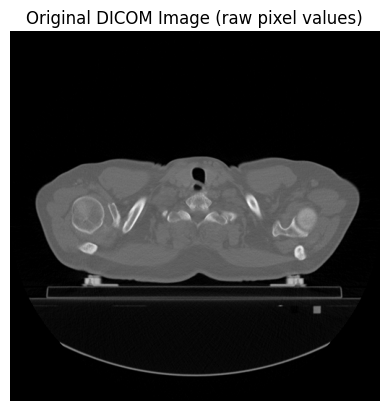

Rescale Slope: 1.0
Rescale Intercept: -1000.0
Pixel Spacing (mm): [0.976562, 0.976562]
Slice Thickness (mm): 3.0


In [ ]:
import pydicom
import matplotlib.pyplot as plt
dicom = pydicom.dcmread(filename)

# Show basic patient and scan info
print("Patient Name:", dicom.PatientName)
print("Modality:", dicom.Modality)
print("Image Dimensions:", dicom.Rows, "x", dicom.Columns)

# Get pixel array (the actual image)
image = dicom.pixel_array

# Show the original image
plt.imshow(image, cmap="gray")
plt.title("Original DICOM Image (raw pixel values)")
plt.axis("off")
plt.show()

# Extract DICOM tags for rescaling and resolution
slope = float(dicom.RescaleSlope)  # the scaling factor used to convert the raw pixel values into Hounsfield Units (HU).
intercept = float(dicom.RescaleIntercept)
pixel_spacing = dicom.PixelSpacing  #  spacing between pixels [mm] [row_spacing, col_spacing] (how much physical distance corresponds to each pixel on the image)
slice_thickness = float(dicom.SliceThickness) # physical distance between two consecutive slices [mm]

print("Rescale Slope:", slope)
print("Rescale Intercept:", intercept)
print("Pixel Spacing (mm):", pixel_spacing)
print("Slice Thickness (mm):", slice_thickness)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: The domain policy has disabled Drive File Stream: https://support.google.com/a/answer/7496409

Now that you have all the necessary information, you can convert the pixel values to HU and plot the CT scan.
- **Q2.1** Convert the pixel values to HU using the correct formula.
- **Q2.2** Plot the three different views of the CT scan: axial, coronal, and sagittal. Make sure to keep the same aspect ratio across all views so that the images are accurately represented and comparable.



- **Q2.3** Are the slides in the right order? if not, reorder the slides correctly using a specific dicom tag.

- **Q2.4** Navigate through the different slides. Do you see anything that captures your attention? If so, where is it located, what might be causing it, and how could this issue be addressed or corrected? (If you prefer to navigate the scan through a graphical interface, you can use the [OHIF viewer](https://viewer-dev.ohif.org/localbasic) and upload the data). \
**Hint**: Look at the region of the mandible. (You do not need to implement your correction strategy)

> *Answer here*

We can observe metal artifacts in the region of the teeth, likely caused by the presence of a metal dental implant. The main reason for this distortion is the extremely high density of metal compared to the surrounding soft and hard tissues. As a result, X-rays are much more strongly attenuated by the metal.

This creates several issues during image reconstruction. One of the key effects
is scattering, where some X-rays are deflected as they pass through the dense material. These scattered rays reach the detector at incorrect positions, introducing noise and inaccuracies into the image. In addition, metal can completely block some X-rays, resulting in missing data and streaking artifacts.

One possible strategy to reduce this issue is to apply post-processing techniques, such as interpolating the corrupted pixels using the values of neighboring, unaffected pixels. This can help to smooth out the artifacted regions and partially restore the anatomical detail.




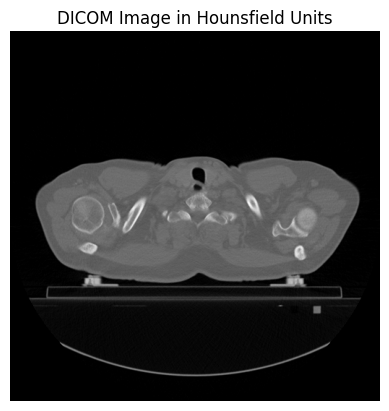

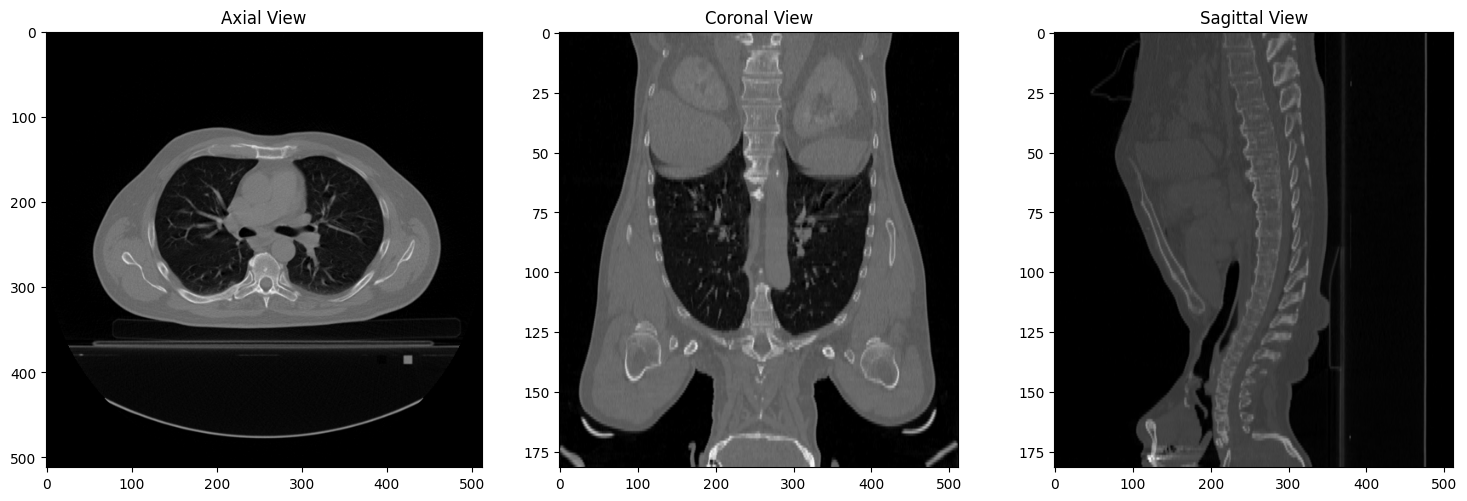

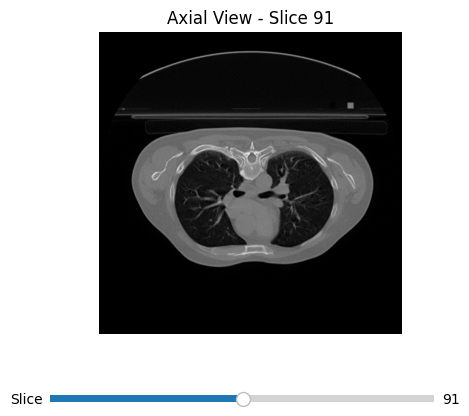

In [ ]:
import numpy as np
# Q2.1
hu_image = image * slope + intercept

# Display the image in Hounsfield Units
plt.imshow(hu_image, cmap="gray")
plt.title("DICOM Image in Hounsfield Units")
plt.axis("off")
plt.show()


# Q2.2
#dicom_files = [f for f in os.listdir(path_to_dicom) if f.endswith(".dcm")]

slices = []
for file in dicom_files:
    #ds = pydicom.dcmread(os.path.join(path_to_dicom, file))
    ds = pydicom.dcmread(file)
    slices.append(ds)

slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

height, width = slices[0].pixel_array.shape

ct_volume = np.stack([s.pixel_array for s in slices])

slope = float(slices[0].RescaleSlope)
intercept = float(slices[0].RescaleIntercept)
ct_volume = ct_volume * slope + intercept   # array 3D: [num_slices, height, width]


pixel_spacing = list(map(float, slices[0].PixelSpacing))  # [dy, dx]
slice_thickness = float(slices[0].SliceThickness)         # dz


dy, dx = pixel_spacing
dz = slice_thickness

# Axial: [y, x]
axial_aspect = dy / dx
# Coronal: [z, x]
coronal_aspect = dz / dx
# Sagittal: [z, y]
sagittal_aspect = dz / dy

axial_slice = ct_volume[ct_volume.shape[0] // 2, :, :]
coronal_slice = ct_volume[:, ct_volume.shape[1] // 2, :]
sagittal_slice = ct_volume[:, :, ct_volume.shape[2] // 2]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial view
axes[0].imshow(axial_slice, cmap='gray', aspect=axial_aspect)
axes[0].set_title('Axial View')

# Coronal view
axes[1].imshow(coronal_slice, cmap='gray', aspect=coronal_aspect)
axes[1].set_title('Coronal View')

# Sagittal view
axes[2].imshow(sagittal_slice, cmap='gray', aspect=sagittal_aspect)
axes[2].set_title('Sagittal View')

plt.tight_layout()
plt.show()

# Q2.3

# Sort the slices based on the z-position (third value of ImagePositionPatient)
slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

# Extract the pixel arrays after sorting
sorted_ct_volume = np.stack([s.pixel_array for s in slices])


# Q2.4
from matplotlib.widgets import Slider

# Crea la figura e l'asse
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# Slice iniziale (la metà del volume)
slice_index = ct_volume.shape[0] // 2
initial_slice = np.flipud(ct_volume[slice_index, :, :])

# Mostra l'immagine
img_display = ax.imshow(initial_slice, cmap='gray', aspect=axial_aspect)
ax.set_title(f'Axial View - Slice {slice_index}')
ax.axis('off')

# Slider per cambiare slice
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])  # [left, bottom, width, height]
slider = Slider(ax_slider, 'Slice', 0, ct_volume.shape[0]-1, valinit=slice_index, valfmt='%0.0f')

# Funzione che aggiorna l'immagine
def update(val):
    idx = int(slider.val)
    new_slice = np.flipud(ct_volume[idx, :, :])
    img_display.set_data(new_slice)
    ax.set_title(f'Axial View - Slice {idx}')
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()



In [ ]:
import ipywidgets as widgets
from IPython.display import display

def show_slice(index):
    plt.figure(figsize=(5, 5))
    plt.imshow(np.flipud(ct_volume[index, :, :]), cmap='gray', aspect=axial_aspect)
    plt.title(f'Axial View - Slice {index}')
    plt.axis('off')
    plt.show()

slider = widgets.IntSlider(min=0, max=ct_volume.shape[0] - 1, step=1, value=slice_index)
widgets.interact(show_slice, index=slider)

interactive(children=(IntSlider(value=91, description='index', max=181), Output()), _dom_classes=('widget-inte…

<function __main__.show_slice(index)>

## 1.2 Data for treatment planning optimization

As using a 3D CT scan for optimization will be too computationally expensive and the conversion of the data to a 3D matrix will be too memory consuming, we will use a 2D slice of the CT scan for the optimization.

 The conversion of the DICOM data to usable numpy arrays can be quite cumbersome; therefore, your nice teaching assistants provided you with compressed numpy arrays concatenated into a dictionary for the segmented organs and numpy arrays for the CT and the beamlet matrix. To access the data, you will need to use the following code:

```python
import numpy as np
# The segmented organs
RTSTUCTS_phase_0 = np.load("data/RTSTRUCT_dict_phase_0.npz", allow_pickle=True)
RTSTUCTS_phase_5 = np.load("data/RTSTRUCT_dict_phase_5.npz", allow_pickle=True)

#example of the RTSTRUCTS dictionary
CTV = RTSTUCTS_phase_0["CTV"]

# The CT scans
ct_phase_0 = np.load("data/CT_phase_0.npy",allow_pickle=True)
ct_phase_5 = np.load("data/CT_phase_5.npy",allow_pickle=True)

# The beamlet matrixes
beamlets_phase_0 = np.load("data/Beamlets_phase_0.npy",allow_pickle=True)
beamlets_phase_5 = np.load("data/Beamlets_phase_5.npy",allow_pickle=True)

```

In the RTSTRUCTS dictionary, you will find the following arrays (the arrays are boolean 512x512 mask) :

- CTV
- Heart
- Lungs
- Liver
- Spinal canal
- Body

As you can see, we provide you 2 slices of 2 different CT scans. Those slices originate from a 4DCT. A 4DCT that records multiple CT scans over time. Here we provide you with 2 different phases of the 4DCT. The first phase is the 0% respiratory phase and the second is the 50% phase.\

We will first use the 0% phase.
- **Q3.1** Explore and plot different HU values of the CT scans for -1000 HU, 0 HU, 500 HU, 1000 HU.
- **Q3.2** To what tissue correspond these HU values?
> *Answer here*

1000 HU: This value corresponds to air.
0 HU: This value corresponds to water (or soft tissues).
500 HU: This value corresponds to muscle or soft tissue.
1000 HU: This value corresponds to bone.

- **Q3.3** Display the different binary masks and overlay them on the CT

**Hint**: use [plt.countour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html)

In [ ]:
# The segmented organs
RTSTUCTS_phase_0 = np.load("data_for_students/data_for_students/data/RTSTRUCT_dict_phase_0.npz", allow_pickle=True)
RTSTUCTS_phase_5 = np.load("data_for_students/data_for_students/data/RTSTRUCT_dict_phase_5.npz", allow_pickle=True)

# example of the RTSTRUCTS dictionary
CTV = RTSTUCTS_phase_0["CTV"]

# The CT scans
ct_phase_0 = np.load("data_for_students/data_for_students/data/CT_phase_0.npy",allow_pickle=True)
ct_phase_5 = np.load("data_for_students/data_for_students/data/CT_phase_5.npy",allow_pickle=True)

# The beamlet matrixes
beamlets_phase_0 = np.load("data_for_students/data_for_students/data/Beamlets_phase_0.npy",allow_pickle=True)
beamlets_phase_5 = np.load("data_for_students/data_for_students/data/Beamlets_phase_5.npy",allow_pickle=True)

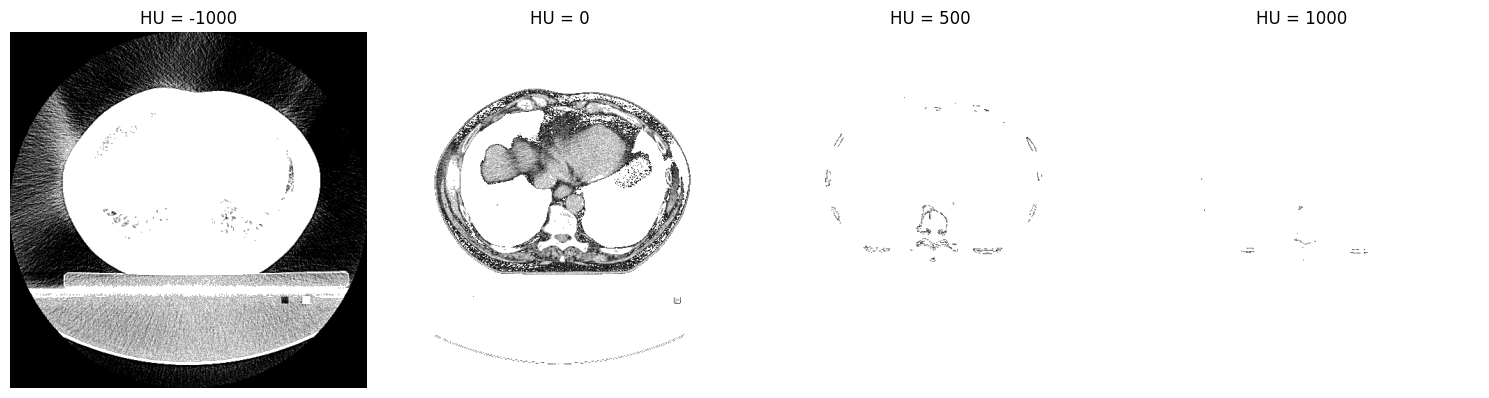

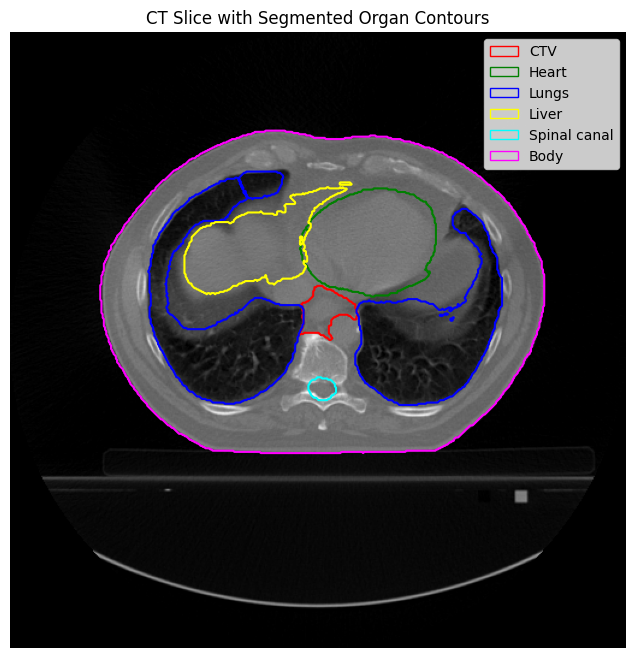

In [ ]:
# Q3.1
# Plot the CT scan at different HU values: -1000 HU, 0 HU, 500 HU, 1000 HU
hu_values = [-1000, 0, 500, 1000]
fig, axes = plt.subplots(1, len(hu_values), figsize=(15, 5))

# Iterate over the HU values and plot the corresponding CT slice
for i, hu_value in enumerate(hu_values):
    # Create a mask for pixels that are close to the HU value
    mask = np.abs(ct_phase_0 - hu_value) < 100  # Consider a range of HU values around each point
    slice_image = np.where(mask, ct_phase_0, np.nan)  # Set other values to NaN for clarity

    axes[i].imshow(slice_image, cmap='gray')
    axes[i].set_title(f"HU = {hu_value}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Q3.3
organs = RTSTUCTS_phase_0.keys()
# Define a color for each organ contour
colors = ["red", "green", "blue", "yellow", "cyan", "magenta"]

# Plot the CT image
plt.figure(figsize=(8, 8))
plt.imshow(ct_phase_0, cmap='gray')
plt.title("CT Slice with Segmented Organ Contours")

# Overlay each binary mask as a contour
for organ, color in zip(organs, colors):
    mask = RTSTUCTS_phase_0[organ]           # Load the binary mask (True = organ)
    plt.contour(mask, colors=color, linewidths=1.5)  # Draw the contour

# Manually add a legend for the colored contours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor=c, label=o) for o, c in zip(organs, colors)]
plt.legend(handles=legend_elements, loc='upper right')

plt.axis('off')  # Remove axis ticks
plt.show()



Now we will explore the pre-computed beamlets. Those have been computed though the use of a Monte-Carlo simulator embeded in the open-source treatment planning system [OpenTPS](https://opentps.org/).

- **Q4.1** Display several beamlets on the 0% phase CT scan. (**e. g.** beamlet index 50, 100, 150 and 200).

**Hint**: use the colormap 'jet' to display the beamlets.

**Hint 2**: each beamlet is stored in a 1D array, you will need to reshape them.

- **Q4.2** To what corresponds the dimension of the beamlet matrix?

>*Answer here*

The beamlet matrix has a shape of (262144, 213).
-The first dimension (262144) corresponds to the number of pixels in the 2D CT slice. Since each CT slice has a resolution of 512 x 512 = 262144 pixels, each row of the matrix represents one pixel position in the CT slice.
-The second dimension (213) corresponds to the number of individual beamlets

- **Q4.3** Display the same index of the uncorrected beamlets on the 50% phase CT scan. What do you observe?

> *Answer here*

When observing the uncorrected beamlets on the 50% phase CT scan, it is evident that the delineations differ from the 0% phase CT scan (other CTV, bigger liver). This can result in the fact that the beamlets do not accurately target the CTV (Clinical Target Volume). Instead, they can affect surrounding organs, such as the heart or the livers, and deliver less dose to the CTV.

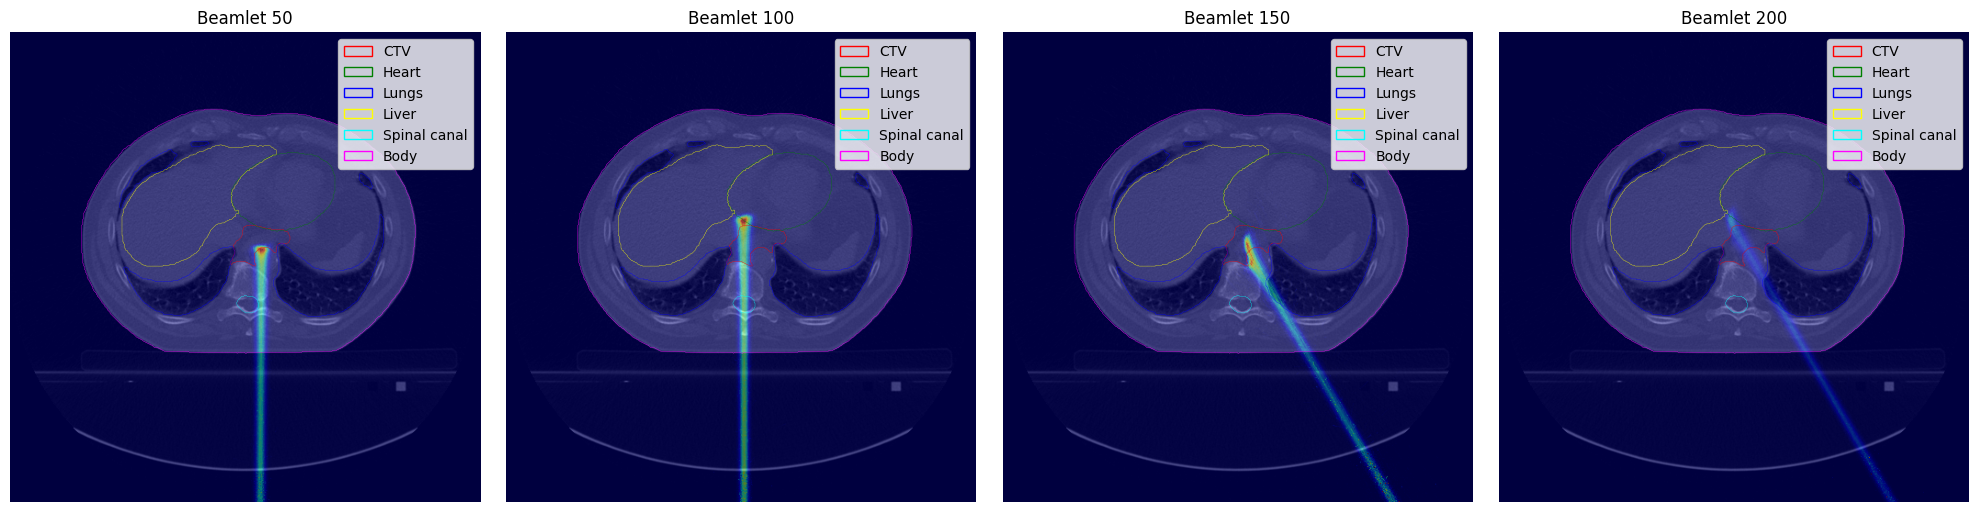

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reshape size (based on the CT and beamlet data dimensions)
shape = (512, 512)

# Beamlet indices to display
indices = [50, 100, 150, 200]

# Load the phase CT slice and the CTV mask
ct = ct_phase_5

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, idx in zip(axes, indices):
    beamlet_reshaped = beamlets_phase_0[:, idx].reshape(shape)

    # Show CT scan in grayscale
    ax.imshow(ct, cmap='gray')

    # Overlay the beamlet with jet colormap and some transparency
    ax.imshow(beamlet_reshaped, cmap='jet', alpha=0.5)

    # Loop over organs and draw their contours
    for organ, color in zip(organs, colors):
        mask = RTSTUCTS_phase_5[organ]  # Load the binary mask (True = organ)
        ax.contour(mask, colors=color, linewidths=0.25)  # Draw the contour for each organ

    # Add a legend
    legend_elements = [Patch(facecolor='none', edgecolor=c, label=o) for o, c in zip(organs, colors)]
    ax.legend(handles=legend_elements, loc='upper right')

    ax.set_title(f"Beamlet {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

- **Q4.4** What do you need to correct in the uncorrected pre-computed beamlets?

**Hint**: The treatment delivery technique used is pencil beam scanning. \
**Hint 2**: Display the beamlet on the CT while contouring the CTV.

> *Answer here*

To correct the uncorrected pre-computed beamlets, you need to adjust their positions to account for respiratory motion. By displaying the beamlets on the CT with CTV contours, it's clear that motion leads to inaccurate targeting. Corrections involve aligning the beamlets with the CTV throughout the breathing cycle using motion-compensated planning.

## 2. Treatment plan optimization

We will now get into the principal part of the lab: the treatment plan optimization. To guide you through this we will go step by step into the optimization process.

### 2.1 Formulating the optimization problem

In intensity modulated proton therapy (IMPT) we can formulate the optimization problem as follows:

\begin{equation}
    \begin{split}
        \min_{\textbf{x}} \{\sum_j w_j f_j(\mathcal{D})\}\\
        \textrm{s.t.} & \quad \mathcal{D} = \mathcal{B}\textbf{x}\\
        &\quad  x\geq0 \quad \forall x \in \textbf{x}\\
    \end{split}
\end{equation}

where the variables are :
<center>

| Variable | Description | Dimension |
|----------------|----------------|----------------|
| $\textbf{D}$   | Dose distribution in 2D | $\mathbb{R}^{n_x \times n_y}$ |
| $\mathcal{D}$  | Dose distribution flattened | $\mathbb{R}^{N}$ |
| $\mathcal{B}$  | Beamlet matrix | $\mathbb{R}^{N \times m}$ |
| $\textbf{x}$   | Beamlet weights | $\mathbb{R}^m$ |
| $f_j$            | Objective function | $\mathbb{R}$ |
| $\sum_j w_j f_j$ | The total objective function| $\mathbb{R}$ |
| $w_j$          | The weight of each objectif | $\mathbb{R}$ |

</center>

To impose positive weights, we will use the following transformation:
\begin{equation}
x_i := u_i^2
\end{equation}

where $u$ is the new optimization variable.

In this session, we will use three types of objective functions :

\begin{equation}
f_{max}(\mathcal{D}) = \frac{1}{N_r} \sum_i^{N_r} \max\{ 0 ; (d_i - d_{presc}) \}^2
\end{equation}
\begin{equation}
f_{min}(\mathcal{D}) = \frac{1}{N_r} \sum_i^{N_r} \min\{ 0 ; (d_i - d_{presc}) \}^2
\end{equation}
\begin{equation}
f_{max-mean}(\mathcal{D}) = \max\{ 0 ; (\frac{1}{N_r} (\sum_i^{N_r} d_i) - d_{presc}) \}^2
\end{equation}

where $d_i$ is the dose at voxel $i$, $d_{presc}$ is the prescription dose and $N_r$ is the number of voxels in the considered region.

As we will use a gradient descent approach to optimize the treatment plan, we will also need to compute the gradient of the objective function with respect to the optimization variable.
- **Q5.1** Write the gradient of the three above-described cost functions.

**Hint**: You will need to use the chain rule. \
**Hint 2**: Think carefully about the dimensions of the gradient.

You can write Latex equations in Markdown cells the following way:

```markdown
\begin{equation}
(a+b)^2 = a^2 + 2ab + b^2
\end{equation}
```

>*Answer here*

Let the dose vector be defined as:

\begin{equation}
\mathcal{D} = \mathcal{B} \mathbf{x} = \mathcal{B}(u^2)
\end{equation}

We compute the gradient of each cost function $f_j$ with respect to the optimization variable $u$, using the chain rule:

\begin{equation}
\frac{\partial f_j}{\partial u} = \frac{\partial f_j}{\partial \mathcal{D}} \cdot \frac{\partial \mathcal{D}}{\partial \mathbf{x}} \cdot \frac{\partial \mathbf{x}}{\partial u}
\end{equation}

We know that:

\begin{equation}
\frac{\partial \mathbf{x}}{\partial u} = 2 diag(u) = 2uI_m
\end{equation}

and

\begin{equation}
\frac{\partial \mathcal{D}}{\partial \mathbf{x}} = \mathcal{B}
\end{equation}

We work only in the region of interest, so we use $\mathcal{D}_r$ and $\mathcal{B}_r$.


1. Gradient of $f_{max}$

\begin{equation}
f_{\text{max}}(\mathcal{D}) = \frac{1}{N_r} \sum_{i=1}^{N_r} \max(0, d_i - d_{\text{presc}})^2
\end{equation}

Derivative w.r.t. $D_r$:

\begin{equation}
\left( \frac{\partial f_{\text{max}}}{\partial \mathcal{D}_r} \right)_i = \left[\frac{2}{N_r}max(0;(d_i-d_{presc})\right]_i
\end{equation}

Gradient w.r.t. $u$ is thus:

\begin{equation}
\nabla_u f_{\text{max}} = \left( \frac{2}{N_r}  \cdot \max(0; \mathcal{D}_r - d_{presc}) \right) \cdot \mathcal{B}_r \cdot 2uI_m
\end{equation}
as described in the pdf.

2. Gradient of $f_{min}$

This is analogues to $f_{max}$:

\begin{equation}
\nabla_u f_{\text{min}} = \left( \frac{2}{N_r}  \cdot \min(0; \mathcal{D}_r - d_{presc}) \right) \cdot \mathcal{B}_r \cdot 2uI_m
\end{equation}

3. Gradient of $f_{max - mean}$

\begin{equation}
f_{\text{max-mean}}(\mathcal{D}) = \max\left(0, \frac{1}{N_r} (\sum_{i=1}^{N_r} d_i) - d_{\text{presc}} \right)^2
\end{equation}

Then


\begin{equation}
\frac{\partial f_{\text{max-mean}}}{\partial \mathcal{D}_r} = \left[\frac{2}{N_r}max(0;((\sum_{i=1}^{N_r} d_i)-d_{presc})\right] \cdot \sum_{i=1}^{N_r}\frac{∂d_i}{∂D} = \frac{2}{N_r}max(0;((\sum_{i=1}^{N_r} d_i)-d_{presc}) \cdot \sum_{i=1}^{N_r} [δ_{ik}]_k = \frac{2}{N_r} [max(0;((\sum_{i=1}^{N_r} d_i)-d_{presc})]_k
\end{equation}

so every value of the vector is the same of dimension (1,N_r).

The gradient with respect to $u$ is then

\begin{equation}
\nabla_u f_{\text{max-mean}} = \frac{2}{N_r} [max(0;((\sum_{i=1}^{N_r} d_i)-d_{presc})]_k  \cdot \mathcal{B}_r \cdot 2uI_m
\end{equation}

### 2.2 Implementation of the cost function

The constraints you will need to implement are the following:

<center>

| Region | Constraint             |
|----------------|------------------------|
| CTV | $D_{max} < 60 Gy$      |
| CTV | $D_{min} > 50.4 Gy$    |
| Heart | $D_{max-mean} < 26 Gy$ |
| Lungs | $D_{max-mean} < 7 Gy$  |
| Liver | $D_{max-mean} < 32 Gy$ |
| Spinal canal | $D_{max} < 20 Gy$      |
| Body | $D_{max} < 10 Gy$      |

</center>

Those constraints are based on the *QUANTEC* tables that you can find in the following paper: "The Use of Normal Tissue Complication Probability (NTCP) Models in the Clinic" by Marks et al. 2010.
(doi:10.1016/j.ijrobp.2009.07.1754.)

- **Q6.1** Implement the evaluation of the cost function
- **Q6.2** Implement the gradient of the cost function

In [ ]:
def total_cost(u, B, masks, dp_dict, weight_vector):
    """
    Compute total cost from max, min, and mean constraints per region.
    """
    x = u**2                     # beamlet weights must be non-negative
    D = B @ x                    # total dose at each voxel
    cost = 0.0

    w_max, w_min, w_mean = weight_vector  # weights for each objective

    for region, constraints in dp_dict.items():
        D_r = D[masks[region]]            # dose in region of interest (ROI)
        Nr = len(D_r)                     # number of voxels in region

        if "max" in constraints:   #if a maximum dose is prescribed
            d_max = D_r - constraints["max"]
            cost += w_max * np.mean(np.maximum(0, d_max)**2)  # more efficient than sum / Nr

        if "min" in constraints:   #if a minimum dose is prescribed
            d_min = D_r - constraints["min"]
            cost += w_min * np.mean(np.minimum(0, d_min)**2)

        if "mean" in constraints:   #if a mean-max dose is prescribed
            mean_d = np.mean(D_r)
            excess = max(0, mean_d - constraints["mean"])
            cost += w_mean * excess**2

    return cost



def total_gradient(u, B, masks, dp_dict, weight_vector):
    """
    Compute total gradient for the cost function with multiple region constraints.
    """
    x = u**2                     # optimization variable: beamlet weights
    D = B @ x                    # dose vector for all voxels
    grad = np.zeros_like(u)     # initialize gradient

    w_max, w_min, w_mean = weight_vector

    for region, constraints in dp_dict.items():
        mask = masks[region]       # boolean mask for ROI
        D_r = D[mask]              # dose in ROI
        B_r = B[mask]              # beamlets restricted to ROI (shape: Nr x m)
        Nr = len(D_r)

        if "max" in constraints:
            d_max = D_r - constraints["max"]
            g_max = (2 / Nr) * np.maximum(0, d_max)       # gradient of f_max w.r.t. D_r
            grad += w_max * (g_max @ B_r) * 2 * u          # chain rule + reshape

        if "min" in constraints:
            d_min = D_r - constraints["min"]
            g_min = (2 / Nr) * np.minimum(0, d_min)       # gradient of f_min
            grad += w_min * (g_min @ B_r) * 2 * u

        if "mean" in constraints:
            mean_d = np.mean(D_r)
            if mean_d > constraints["mean"]:
                delta = 2 * (mean_d - constraints["mean"]) / (Nr**2)  # scalar prefactor
                g_mean = np.ones(Nr) * delta                          # uniform gradient
                grad += w_mean * (g_mean @ B_r) * 2 * u

    return grad



### 2.3 Gradient descent

Now that you have every ingredient to implement the optimization, you can implement the gradient descent algorithm.
- **Q7.1** Imlement the gradient descent algorithm
- **Q7.2** Optimize your plan with $w_j=1 \enspace \forall j$.
- **Q7.3** Vary the step size, what do you observe?
>*Answer here* Higher step size results in higher updates. This speeds up the process, however, this can lead to divergence if the step is too big.

**Hint**: The optimization process can be quite slow. Try to stay in matrix form as much as possible.

In [ ]:
def gradient_descent(u_init, B, masks, dp_dict, weight_vector,
                     step_size=1e-3, max_iter=500, tol=1e-6, verbose=False):
    """
    Gradient descent for minimizing total_cost(u)

    Parameters:
        u_init:        (m,) array, initial values for u
        B:             (N, m) beamlet matrix
        masks:         dict {region: boolean mask}
        dp_dict:       dict {region: dose prescription}
        weight_vector: [w_max, w_min, w_mean]
        step_size:     learning rate
        max_iter:      maximum number of iterations
        tol:           convergence threshold on gradient norm
        verbose:       print progress info

    Returns:
        u_opt: (m,) array, optimized u
        cost_history: list of total cost at each iteration
    """
    u = u_init.copy()
    cost_history = []

    for i in range(max_iter):
        cost = total_cost(u, B, masks, dp_dict, weight_vector)
        grad = total_gradient(u, B, masks, dp_dict, weight_vector)

        cost_history.append(cost)
        grad_norm = np.linalg.norm(grad)

        if verbose:
            print(f"Iter {i:03d} | Cost: {cost:.6f} | ||grad||: {grad_norm:.2e}", end = "\r")

        if grad_norm < tol:
            break

        u -= step_size * grad
        u = np.clip(u, 0, None)  # enforce non-negativity

    return u, cost_history


B = beamlets_phase_0
# Ensure all masks are 1D to match D.shape = (262144,)
dp_dict = {
    "CTV": {"max": 60.0, "min": 50.4},
    "Heart": {"mean": 26.0},
    "Lungs": {"mean": 7.0},
    "Liver": {"mean": 32.0},
    "Spinal canal": {"max": 20.0},
    "Body": {"max": 10.0},
}
masks = {
    region: RTSTUCTS_phase_0[region].flatten()
    for region in dp_dict
}


# Step 1: Initialize u (random or constant)
u0 = np.ones(B.shape[1]) * 0.1  # or: np.random.randn(B.shape[1]) * 0.1

# Step 2: Choose weight vector [w_max, w_min, w_mean]
weights = [1.0, 1.0, 1.0]

# Step 3: Run optimization
u_opt, cost_history = gradient_descent(
    u_init=u0,
    B=B,
    masks=masks,
    dp_dict=dp_dict,
    weight_vector=weights,
    step_size=1,
    max_iter=100,
    tol=1e-6,
    verbose=True
)

# Step 4: Retrieve final solution
x_opt = u_opt**2
D_opt = B @ x_opt

In [ ]:
from scipy.optimize import minimize

# an alternative of implementing an optimization
def scipy_objective(u, B, masks, dp_dict, weight_vector):
    cost = total_cost(u, B, masks, dp_dict, weight_vector)
    grad = total_gradient(u, B, masks, dp_dict, weight_vector)
    return cost, grad



u0 = np.random.randn(B.shape[1]) * 0.1
weights = [1.0, 1.0, 1.0]

# Use an unconstrained optimizer like BFGS
result = minimize(
    fun=lambda u: scipy_objective(u, B, masks, dp_dict, weights),
    x0=u0,
    method='BFGS',
    jac=True, #have the graient
    options={'maxiter': 1000, 'disp': True}
)

# Optimal u and corresponding beamlet weights x
u_opt_scipy = result.x
x_opt_scipy = u_opt_scipy**2

Optimization terminated successfully.
         Current function value: 44.672812
         Iterations: 624
         Function evaluations: 642
         Gradient evaluations: 642


### 2.4 Plan evaluation

Now that you have optimized the treatment plan, you can evaluate it. Therefore, you will use the most common tool of treatment plan evaluation: the Dose Volume Histogram (DVH).

Mathematically, we can describe DVH the following way;

Let :
\begin{equation}
     \kappa : \mathbb{R}^+_0 \rightarrow \mathbb{N}_0 \enspace | \enspace D \rightarrow \kappa(D) \enspace,
\end{equation}

and the bins

\begin{equation}
    \begin{split}
        k \in \mathcal{K} := \{0,...,K\}\\
        \textrm{s.t.} \quad & \kappa(0)=0\\
        & \kappa(D_{max}) = K \enspace. \\
    \end{split}
\end{equation}

Then the DVH for a volume of $N_r$ elementary isotropic voxels in a region r, each receiving a dose $d_i$ is defined by :

\begin{equation}
    h_k = \sum_{i=1}^N \delta_{k, \kappa(d_i)} \enspace,
\end{equation}

\begin{equation}
    \textrm{DVH}_k = \frac{100\%}{N} \sum_{j=k}^K h_j \enspace.
\end{equation}


In words, the DVH is: on the x-axis a certain dose value and on the y-axis the percentage of voxels that received at least this dose.

- **Q8.1** Implement the DVH function \
**Hint**: The functions [np.histogram](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html), [np.cumsum](https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html) and [np.flip](https://numpy.org/doc/stable/reference/generated/numpy.flip.html) can be useful.
- **Q8.2** Compute the DVH for the CTV, Heart, Lungs, Liver, and Spinal canal
- **Q8.3** What do you observe with respect to the above-described constraints?
>*Answer here*   
- The CTV receives doses ranging up to nearly 100 Gy. Although the majority of voxels are within the desired range, a small portion of the volume receives more than 60 Gy, violating the constraint on maximum dose. This indicates that the optimization had to run longer or that the weights are not chosen
-The heart DVH drops off sharply before 26 Gy, indicating that most of the volume receives less than the threshold
-The DVH curve for the lungs shows that a non-negligible portion of the lung volume receives doses up to 20 Gy. but many voxels stay under 7 Gy
-The liver DVH shows an extremely steep decline before 10 Gy
-The dose to the spinal canal drops quickly after about 20 Gy. A small fraction may exceed the 20 Gy threshold, which might risk violating the constraint

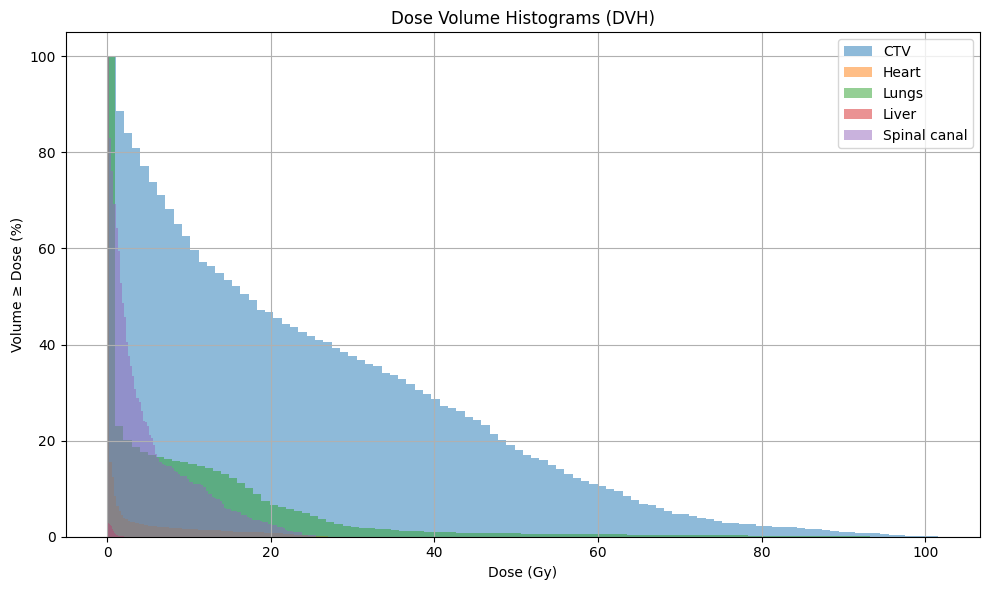

In [ ]:
# Compute dose
D_opt = B @ x_opt  # shape: (262144,)

# DVH computation function
def compute_dvh(dose_region, num_bins=100, dose_max=None):
    if dose_max is None:
        dose_max = np.max(dose_region)
    hist, bin_edges = np.histogram(dose_region, bins=num_bins, range=(0, dose_max))
    cumulative = np.cumsum(hist[::-1])[::-1]
    dvh = cumulative / len(dose_region) * 100
    return bin_edges[:-1], dvh

# Compute DVH for selected regions
selected_regions = ["CTV", "Heart", "Lungs", "Liver", "Spinal canal"]
dvh_data = {}

for region in selected_regions:
    dose_r = D_opt[masks[region]]
    bins, dvh = compute_dvh(dose_r)
    dvh_data[region] = (bins, dvh)

# Plot DVHs
plt.figure(figsize=(10, 6))
for region in selected_regions:
    bins, dvh = dvh_data[region]
    #plt.plot(bins, dvh, label=region)
    plt.bar(bins, dvh, width=bins[1]-bins[0], align='edge', alpha=0.5, label=region)

plt.xlabel("Dose (Gy)")
plt.ylabel("Volume ≥ Dose (%)")
plt.title("Dose Volume Histograms (DVH)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- **Q8.4** Compute the D98 and D2 for the CTV, Heart, Lungs, Liver, and Spinal canal
- **Q8.5** Compute D98-D2 for the CTV, Heart, Lungs, Liver, and Spinal canal
- **Q8.6** What do you observe with respect to the above-described constraints?
>*Answer here*
-CTV:
D98 = 0.00 Gy and D2 = 82.50 Gy indicate a critical issue. The target receives almost no dose in most of its volume, while a small portion is highly overdosed.
-Heart:
D98 = 0.00 Gy, D2 = 6.90 Gy → Most of the heart receives no dose, and the maximum dose is well below 26 Gy. Constraint respected.
-Lungs:
D2 = 30.27 Gy indicates a significant hotspot, likely pushing the mean dose above 7 Gy. D98 = 0.00 Gy shows that most of the lungs are spared. Constraint likely not respected.
-Liver:
Very low doses throughout the organ (D2 = 0.54 Gy). Constraint respected.
-Spinal canal:
D98 = 0.01 Gy and D2 = 21.30 Gy → The maximum dose exceeds the allowed limit of 20 Gy. Constraint not respected.

In [ ]:
def compute_Dx(dose_region, x_percent):
    """
    Compute Dx: the dose received by at least x% of voxels in a region.

    Parameters:
        dose_region: 1D array of dose values for a given region
        x_percent: float, e.g. 98 for D98 or 2 for D2

    Returns:
        Dx: float, the dose value such that x% of voxels receive at least this much dose
    """
    sorted_doses = np.sort(dose_region)[::-1]  # Sort doses from highest to lowest
    index = int(np.ceil((x_percent / 100) * len(sorted_doses))) - 1  # Find index for x%
    return sorted_doses[index]  # Return the dose at that index


regions = ["CTV", "Heart", "Lungs", "Liver", "Spinal canal"]

print(f"{'Region':<15} {'D98 (Gy)':>10} {'D2 (Gy)':>10} {'D98 - D2 (Gy)':>15}")
print("-" * 45)

# Loop over each region and compute metrics
for region in regions:
    dose_r = D_opt[masks[region]]       # Extract doses for the region using mask
    D98 = compute_Dx(dose_r, 98)        # Dose received by at least 98% of voxels
    D2  = compute_Dx(dose_r, 2)         # Dose received by at least 2% of voxels
    print(f"{region:<15} {D98:10.2f} {D2:10.2f} {D98 - D2:15.2f}")  # Output results

Region            D98 (Gy)    D2 (Gy)   D98 - D2 (Gy)
---------------------------------------------
CTV                   0.00      82.50          -82.50
Heart                 0.00       6.90           -6.90
Lungs                 0.00      30.27          -30.27
Liver                 0.00       0.54           -0.54
Spinal canal          0.01      21.30          -21.29


- **Q8.7** Play with the $w_j$ values to reach the optimal plan.
- **Q8.8** What do you observe with respect to the above-described constraints?
>*Answer here*

Adjusting the weights had some effect on dose distribution. Increasing w_min (e.g. [1, 5, 0]) slightly improved D98 for the CTV, but D98 remained too low and D2 too high in all cases. None of the tested combinations satisfied the clinical constraints. More advanced optimization or better initial conditions may be required.

In [ ]:
# Try a few different weight settings and compare D98, D2 for CTV
for weights in [[1,1,1], [1,5,0], [2,6,0], [1,1,3]]:
    print(f"\nTrying weights = {weights}")
    u_opt, _ = gradient_descent(u0, B, masks, dp_dict, weights, step_size=1e-3, max_iter=300, verbose=False)
    x_opt = u_opt**2
    D_opt = B @ x_opt
    D98 = compute_Dx(D_opt[masks["CTV"]], 98)
    D2  = compute_Dx(D_opt[masks["CTV"]], 2)
    print(f"CTV D98 = {D98:.2f}, D2 = {D2:.2f}, Homogeneity = {D98 - D2:.2f}")


Trying weights = [1, 1, 1]
CTV D98 = 0.05, D2 = 1.81, Homogeneity = -1.76

Trying weights = [1, 5, 0]
CTV D98 = 15.42, D2 = 79.66, Homogeneity = -64.24

Trying weights = [2, 6, 0]
CTV D98 = 19.00, D2 = 77.15, Homogeneity = -58.14

Trying weights = [1, 1, 3]
CTV D98 = 0.05, D2 = 1.81, Homogeneity = -1.76


### 2.5 Phase analysis

Now that you have optimized the treatment plan for the 0% phase, you will explore what happens when you use the 50% phase.

- **Q9.1** Keep the same weights and compute the dose distribution for the 50% phase with the correct beamlets and CT.
- **Q9.2** What do you observe? (Do not forget to display the RTSTRUCTS masks)
>*Answer here*

In the 50% phase, the dose distribution shifts due to anatomical changes, and the high-dose region no longer aligns well with the CTV. As a result, the target receives much less dose, while nearby healthy tissues may be exposed unintentionally. This shows that the plan optimized for the 0% phase is not robust to respiratory motion.


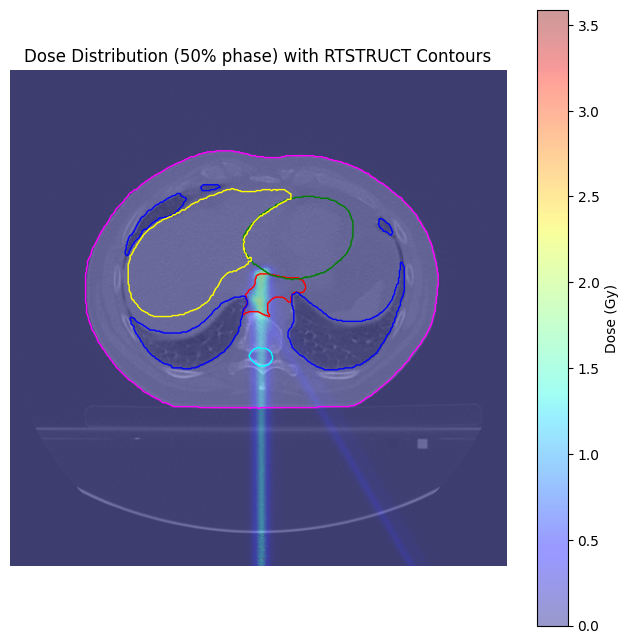

In [ ]:
# Q9.1 - Dose on 50% phase using same weights
B_50 = beamlets_phase_5
D_50 = B_50 @ x_opt  # dose in flattened format (1D)

# Reshape dose to 2D shape for visualization
dose_map_50 = D_50.reshape(ct_phase_5.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(ct_phase_5, cmap='gray', alpha=0.6)
im = plt.imshow(dose_map_50, cmap='jet', alpha=0.4)

# Overlay
for organ, color in zip(RTSTUCTS_phase_5.keys(), colors):
    mask = RTSTUCTS_phase_5[organ]
    plt.contour(mask, colors=color, linewidths=1)

plt.title("Dose Distribution (50% phase) with RTSTRUCT Contours")
plt.axis("off")
plt.colorbar(im, label="Dose (Gy)")
plt.show()

- **Q9.3** Compute the DVH for the 50% phase.
- **Q9.4** Overlay the DVH of the 0% phase and the 50% phase on the same plot.
- **Q9.5** What do you observe?
>*Answer here*
In the 50% phase, the CTV receives significantly less dose, as shown by the leftward shift of its DVH. Some organs at risk receive more dose. This indicates that the plan optimized for the 0% phase is not robust to motion and may lead to underdosage of the tumor and higher risk to nearby organs.


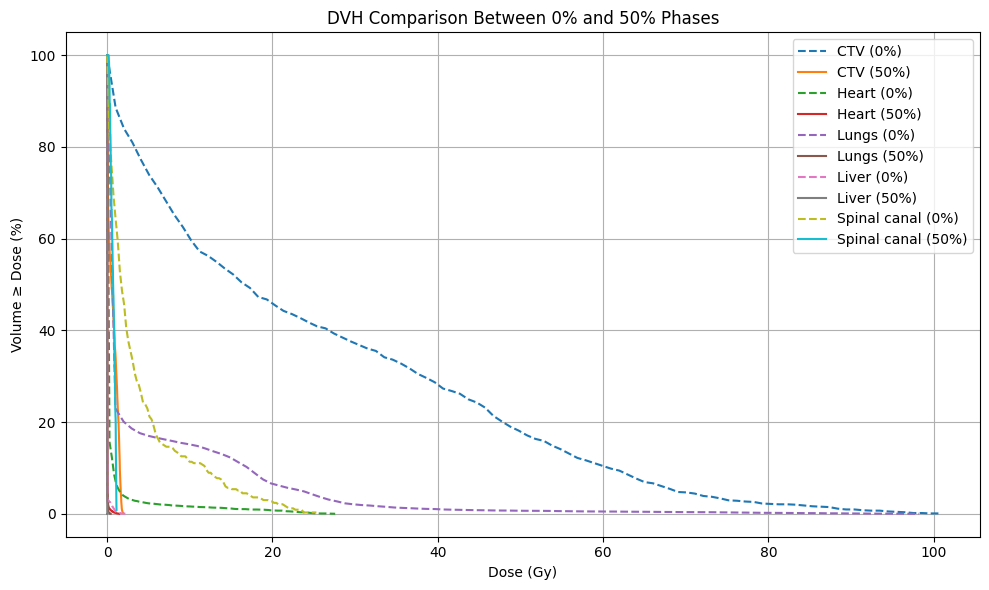

In [ ]:
# Q9.3 - Compute DVH for 50% phase
def compute_dvh(dose_region, num_bins=100, dose_max=None):
    if dose_max is None:
        dose_max = np.max(dose_region)
    hist, bin_edges = np.histogram(dose_region, bins=num_bins, range=(0, dose_max))
    cumulative = np.cumsum(hist[::-1])[::-1]
    dvh = cumulative / len(dose_region) * 100
    return bin_edges[:-1], dvh

# Prepara DVH per la fase 50%
dvh_data_phase_5 = {}
selected_regions = ["CTV", "Heart", "Lungs", "Liver", "Spinal canal"]

for region in selected_regions:
    dose_r_50 = D_50[RTSTUCTS_phase_5[region].flatten()]
    bins, dvh = compute_dvh(dose_r_50)
    dvh_data_phase_5[region] = (bins, dvh)

# Q9.4 - Overlay delle curve
plt.figure(figsize=(10, 6))

for region in selected_regions:
    bins_0, dvh_0 = dvh_data[region]  # DVH fase 0%
    bins_5, dvh_5 = dvh_data_phase_5[region]  # DVH fase 50%

    plt.plot(bins_0, dvh_0, linestyle='--', label=f"{region} (0%)")
    plt.plot(bins_5, dvh_5, linestyle='-', label=f"{region} (50%)")

plt.xlabel("Dose (Gy)")
plt.ylabel("Volume ≥ Dose (%)")
plt.title("DVH Comparison Between 0% and 50% Phases")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Let us now suppose that you have the corrected beamlets for the 50% phase at your disposition but that you do not know in which phase is the patient during the delivery. We will explore some strategies to ensure proper target coverage. Answer the following questions based on the course and some of your own research (do not forget to cite your sources).

- **Q9.6** What strategy can you put in place regarding the treatment delivery to ensure proper target coverage?
>*Answer here*

One effective strategy is to use **respiratory gating** or **breath-hold techniques**, which deliver the dose only during specific, stable phases of the respiratory cycle (e.g., exhale phase). This reduces the impact of motion and improves alignment between the beams and the target.

Another approach is **image-guided radiotherapy (IGRT)**, where frequent imaging (e.g., CBCT, fluoroscopy) is used to verify the tumor position just before or even during delivery. This enables adjustments or corrections in real time to ensure dose is delivered accurately to the moving target.

Source: Bortfeld et al., "Motion management in particle therapy," *Radiotherapy and Oncology*, 2018.  
- **Q9.7** What strategy can you put in place regarding the treatment optimization to ensure proper target coverage?
>*Answer here*

A robust strategy is to use **robust optimization**, which explicitly considers anatomical uncertainties (e.g., motion between respiratory phases) during the plan optimization. Instead of optimizing for one phase, the objective function includes multiple possible anatomical scenarios.

A common approach is **worst-case optimization**: it ensures acceptable coverage even in the worst phase by minimizing the worst-case cost function across all considered scenarios.


- **Q9.8** Write a new cost function that would ensure proper target coverage.
>*Answer here*

To ensure robust target coverage across anatomical motion (e.g., different respiratory phases), we propose the following cost function:

**Cost(x) = Σₚ [ w_min · ||(Dₚ_min - Dₚ[CTV])₊||² + w_max · ||(Dₚ[CTV] - Dₚ_max)₊||² + w_OAR · Σ_o ||(Dₚ[OARₒ] - Dₚ[o_mean])₊||² ]**

Where:
- The sum is over multiple anatomical phases p (e.g., 0%, 50%)
- Dₚ is the dose map in phase p, computed as Dₚ = Bₚ · x
- (·)₊ denotes the positive part (i.e., max(0, ·))
- Dₚ_min and Dₚ_max are the minimum and maximum acceptable dose for the CTV
- o_mean is the mean dose threshold for organ at risk o
- w_min, w_max, w_OAR are tunable weights for CTV underdose, overdose, and OAR sparing respectively

This function penalizes:
- Underdose to the CTV (to ensure D98 > target)
- Overdose to the CTV (to ensure D2 < limit)
- Excess dose to organs at risk (to preserve normal tissue)

It considers all phases during optimization, and helps build a plan that is robust to motion.

**This is a form of scenario-based robust optimization.**


## A. Bonuses

In this section, we will propose you some bonus questions. You can choose to answer to one of them (or all, but it will not get you more points).

The answers to these questions will be based on your own research, therefore remember to cite your sources. (Do not worry, the following questions will not ask you to much research).

### A.1 Tumor control probability and normal tissue complication probability

The tumor control probability (TCP) is a measure of the probability of tumor control after treatment. As there are numerous way of expressing the TCP, we will ask you to focus on the one based on the *linear quadratic surviving fraction*.

- **QA1.1** Write the two main TCP models that exist based on the linear quadratic surviving fraction and describe their parameters (with their units) as their differences.\

Two main models are commonly used to estimate Tumor Control Probability (TCP) based on the linear-quadratic (LQ) surviving fraction: the **Poisson TCP model** and the **logistic TCP model**.

The **Poisson TCP model** assumes that tumor control is achieved when no clonogenic cells survive the treatment. It uses the LQ model to estimate the surviving fraction:

\begin{equation}
SF(D) = e^{-\alpha D - \beta D^2}
\end{equation}

where:
- $D$ is the total dose in Gray [Gy]
- $\alpha$ is the linear radiosensitivity parameter [Gy$^{-1}$]
- $\beta$ is the quadratic radiosensitivity parameter [Gy$^{-2}$]

The TCP is then given by:

\begin{equation}
TCP = e^{-N_0 \cdot SF(D)}
\end{equation}

where $N_0$ is the number of clonogenic tumor cells (unitless).

The **logistic TCP model** is an empirical model that describes the probability of tumor control as a sigmoidal function of dose:

\begin{equation}
TCP = \frac{1}{1 + \left( \frac{D_{50}}{D} \right)^\gamma}
\end{equation}

where:
- $D_{50}$ is the dose resulting in 50% tumor control [Gy]
- $\gamma$ is a dimensionless parameter describing the steepness of the curve

The key difference between the two models is that the Poisson model is biologically motivated and based on clonogenic cell survival, while the logistic model is empirical and fits observed clinical outcomes.



10.4103/0971-6203.89971

- **QA1.2** Implement the two models and plot the TCP as a function of the dose for the 0% and 50% phases.
- **QA1.3** What do you observe?
>*Answer here*



In [ ]:
def compute_tcp(D, model="poisson", alpha=0.3, beta=0.03, N0=1e6, D50=50, gamma=5):
    """
    Compute voxel-wise TCP using either Poisson or Logistic model.

    Parameters:
        D: dose array (flattened, 1D)
        model: "poisson" or "logistic"
        alpha, beta, N0: Poisson model parameters [Gy^-1], [Gy^-2], clonogenic cells
        D50, gamma: Logistic model parameters (dose at which TCP = 50%, slope)

    Returns:
        TCP: array same shape as D
    """
    if model == "poisson":
        SF = np.exp(-alpha * D - beta * D**2)
        return np.exp(-N0 * SF)

    elif model == "logistic":
        tcp = 1 / (1 + (D50 / np.maximum(D, 1e-6))**gamma)  # avoid div by zero
        return tcp

    else:
        raise ValueError("model must be 'poisson' or 'logistic'")


# Compute voxel dose from optimized beamlet weights
D0 = beamlets_phase_0 @ x_opt   # shape (262144,)
D5 = beamlets_phase_5 @ x_opt

# Choose model: "poisson" or "logistic"
model_choice = "poisson"

# Compute TCP maps
tcp_0 = compute_tcp(D0, model=model_choice)
tcp_5 = compute_tcp(D5, model=model_choice)

# Reshape for display
tcp_0_2D = tcp_0.reshape(512, 512)
tcp_5_2D = tcp_5.reshape(512, 512)

from matplotlib.patches import Patch

# Inputs:
# - ct: already loaded 2D CT image
# - tcp_map: TCP values reshaped to (512, 512), e.g. tcp_0_2D or tcp_5_2D
# - organs: list of organ names
# - colors: list of corresponding colors
# - phase: dictionary of organ masks

def plot_tcp_overlay(ct, tcp_map, phase, organs, colors, title="TCP map with contours"):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Show CT in grayscale
    ax.imshow(ct, cmap='gray')

    # Overlay TCP heatmap
    im = ax.imshow(tcp_map, cmap='viridis', alpha=0.5, vmin=0, vmax=1)

    # Contours for each organ
    for organ, color in zip(organs, colors):
        if organ in phase:
            mask = phase[organ]
            ax.contour(mask, colors=color, linewidths=0.5)

    # Legend
    legend_elements = [Patch(facecolor='none', edgecolor=c, label=o) for o, c in zip(organs, colors)]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, label="TCP")
    plt.tight_layout()
    plt.show()


# Define organs and matching colors (same order as your beamlet plot)
organs = ["CTV", "Heart", "Lungs", "Liver", "Spinal canal"]
colors = ['red', 'orange', 'green', 'blue', 'purple']

# Plot TCP for 0% phase
plot_tcp_overlay(ct_phase_0, tcp_0_2D,RTSTUCTS_phase_0,  organs, colors, title="TCP (0% phase)")

# Plot TCP for 50% phase (if available)
plot_tcp_overlay(ct_phase_5, tcp_5_2D,RTSTUCTS_phase_5, organs, colors, title="TCP (50% phase)")

# Additional plot: TCP as a function of dose for both models
D_vals = np.linspace(0, 80, 500)
SF_poisson = np.exp(-alpha * D_vals - beta * D_vals**2)
tcp_poisson = np.exp(-N0 * SF_poisson)
tcp_logistic = 1 / (1 + (D50 / np.maximum(D_vals, 1e-6))**gamma)

plt.figure(figsize=(8, 5))
plt.plot(D_vals, tcp_poisson, label="Poisson model", color="blue")
plt.plot(D_vals, tcp_logistic, label="Logistic model", color="green")
plt.xlabel("Dose [Gy]")
plt.ylabel("TCP")
plt.title("Tumor Control Probability (TCP) vs Dose")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


NameError: name 'x_opt' is not defined

Now you will explore the normal tissue complication probability (NTCP). Again as there are even more expression for the NTCP you will focus on the one based on the linear quadratic surviving fraction.

- **QA1.4** What are the two type of organs at risk that exist and how do they differ?

Organs at risk can be classified as either serial or parallel.
Serial organs, such as the spinal cord, fail if a small part receives a high dose, so their function depends on the maximum dose.
Parallel organs, like the lungs, liver, or heart, can tolerate local damage and are instead sensitive to the average dose across the whole organ.

- **QA1.5** What are their respective NTCP model ?
The NTCP for both types is often modeled using the Lyman-Kutcher-Burman (LKB) model.
For serial organs, the effective dose is taken as the maximum dose; for parallel organs, it is the mean dose.
The NTCP is calculated using the normal cumulative distribution:,
\begin{equation}
  NTCP = \phi \left( \frac{D_{eff}-D_{50}}{mD_{50}} \right)
\end{equation}
https://doi.org/10.1002/mp.15365

-  **QA1.6** Compute the NTCP for the heart, lungs, liver and spinal canal using the correct model each time


In [ ]:
from scipy.stats import norm

def compute_ntcp(D_region, D50, m, model="parallel"):
    """
    Compute NTCP using LKB model based on organ type.

    Parameters:
        D_region: array of voxel doses in the organ
        D50: dose at 50% complication probability
        m: slope of response
        model: "serial" or "parallel"

    Returns:
        NTCP value (float)
    """
    if model == "parallel":
        D_eff = np.mean(D_region)
    elif model == "serial":
        D_eff = np.max(D_region)
    else:
        raise ValueError("model must be 'serial' or 'parallel'")

    t = (D_eff - D50) / (m * D50)
    return norm.cdf(t)

#have to find realistic D_50 and m values in literature!
organs = {
    "Heart": {"model": "parallel", "D50": 52, "m": 0.28},
    "Lungs": {"model": "parallel", "D50": 24.5, "m": 0.18},
    "Liver": {"model": "parallel", "D50": 39, "m": 0.25},
    "Spinal canal": {"model": "serial", "D50": 45, "m": 0.1},
}

print(f"{'Organ':<15} {'NTCP (%)':>10}")
print("-" * 25)

for organ, params in organs.items():
    D_region = D_opt[masks[organ]]
    ntcp = compute_ntcp(D_region, D50=params["D50"], m=params["m"], model=params["model"])
    print(f"{organ:<15} {ntcp * 100:10.2f}")

Organ             NTCP (%)
-------------------------
Heart                 0.02
Lungs                 0.00
Liver                 0.00
Spinal canal          0.00


### A.2 Equivalent Uniform Dose

In this question, you will explore the concept of equivalent uniform dose (EUD).

- **QA2.1** What is the paradygm of the equivalent uniform dose?
>*Answer here*

You will now compare to type of fomulation of the equivalent uniform dose : the EUD based on the *linear quadratic surviving fraction* and the EUD based on the *generalized equivalent uniform dose* (also called gEUD).
- **QA2.3** What are their respective formula and what do their parameters mean?
>*Answer here*
- **QA2.4** Implement the two models of EUD for the CTV, heart, lungs, liver and spinal canal for the 0% and 50% phases.
- **QA2.5** What do you observe?
>*Answer here*

In [ ]:
# code here

## Instruction for submission

- This notebook is due on **Sunday, May 25, at 23:59:59**.
- Send your filled notebook be email to the two assisants with the naming convention: **Lastname1_Lastname2_LGBIO2070_Lab3.ipynb**.
- To not forget to write your names at the beginning of the notebook.
- All the cells should be pre-run, and the notebook should be clean.
- Do not send the numpy and DICOM files, only the notebook.
- Keep the numpy data under the "data/" folder and the DICOM under the "CT/" folder.
